Code to process LAHM data imported as a .csv file

In [2]:
#generic resources, not all necessarily needed for this
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import plotly.express as px
import plotly.graph_objects as go
import csv
import pandas as pd


In [3]:
#add data to list based on given parameter (currently depth but could also do based on site, etc)
depth1 = []
with open('LAHM_data.csv', newline = '') as csvfile:
    file = csv.DictReader(csvfile)
    # next(reader) #removes header row
    for row in file:
        Depth = row['Depth']
        if float(Depth[0]) == 1:
            ngperg = float(row['schmitt_ngperg'])
            depth1.append(ngperg)
    # print(depth2)
    
depth2 =[]
with open('LAHM_data.csv', newline = '') as csvfile:
    file = csv.DictReader(csvfile)
    # next(reader) #removes header row
    for row in file:
        Depth = row['Depth']
        if Depth[0] == '2':
            ngperg = float(row['schmitt_ngperg'])
            depth2.append(ngperg)

In [4]:
#calculate mean and standard error 
mean = np.mean(depth1)
print(mean)
sem = np.std(depth1, ddof=1) / np.sqrt(np.size(depth2))
print(sem)

mean = np.mean(depth2)
print(mean)
sem = np.std(depth2, ddof=1) / np.sqrt(np.size(depth2))
print(sem)

151.6061860159375
29.16753276594396
26.541138542789476
2.9470614170762817


In [5]:
data = pd.read_csv('LAHM_data.csv')
data21 = pd.read_csv('LAHM_21.csv')
impure = pd.read_csv('Impurities.csv')
datadates = pd.read_csv('datawdates.csv')

In [6]:
data.columns

Index(['Sample', 'Site', 'Depth_Range', 'Depth', 'A', 't0',
       'schmitt_micrograms', 'schmitt_ngperg'],
      dtype='object')

In [7]:
impurities = ['Dirt', 'Plant', 'Exhaust', 'Fullerene']

#mean etc for pollen
pmean = np.mean(impure['t0'][impure['Type'] == 'Plant'])
pstd = np.std(impure['t0'][impure['Type'] == 'Plant'], ddof=1)

#mean etc for dirt
dmean = np.mean(impure['t0'][impure['Type'] == 'Dirt'])
dstd = np.std(impure['t0'][impure['Type'] == 'Dirt'], ddof=1)

#mean etc for exhaust
emean = np.mean(impure['t0'][impure['Type'] == 'Exhaust'])
estd = np.std(impure['t0'][impure['Type'] == 'Exhaust'], ddof=1)
print(emean)
print(estd)

#mean etc for fullerene
fmean = np.mean(impure['t0'][impure['Type'] == 'Fullerene'])
fstd = np.std(impure['t0'][impure['Type'] == 'Fullerene'], ddof=1)

3.47685
0.15805320834031394


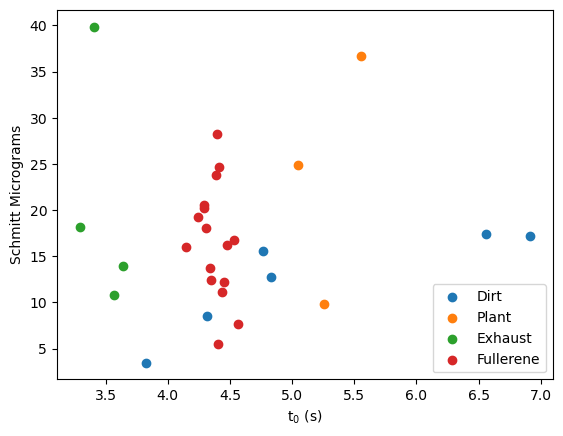

In [8]:
for impurity in impurities:
    x = impure['t0'][impure['Type'] == impurity]
    y = impure['schmitt_micrograms'][impure['Type'] == impurity]
    plt.scatter(x,y,label = str(impurity))
plt.xlabel('t$_0$ (s)')
plt.ylabel('Schmitt Micrograms')
plt.legend(loc = 'lower right')
plt.show()

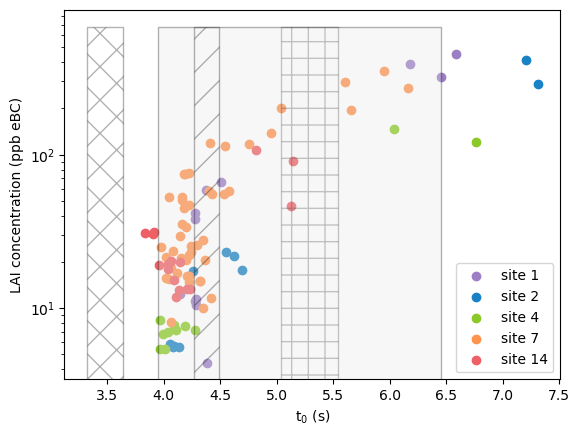

In [9]:
sitelist = [1,2,4,7,14]
depthlist = [1,2,3,4,5]
depthshapes = ['s', 'o', 'v', 'P', 'd']
sitecolors = ['#9B7EC4', '#1982C4','#8AC926', '#FF924C', '#EE6065']
recty = [0,np.max(data['schmitt_ngperg'] * 1.5)]
# plt.figure(dpi=500)
for isite in range(len(sitelist)):
    site = sitelist[isite]
    x = data['t0'][data['Site'] == site]
    y = data['schmitt_ngperg'][data['Site'] == site]
    plt.scatter(x,y, color = sitecolors[isite],label = 'site ' + str(site))
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
# plt.grid(True)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
plt.legend(loc = 'lower right')
plt.show()

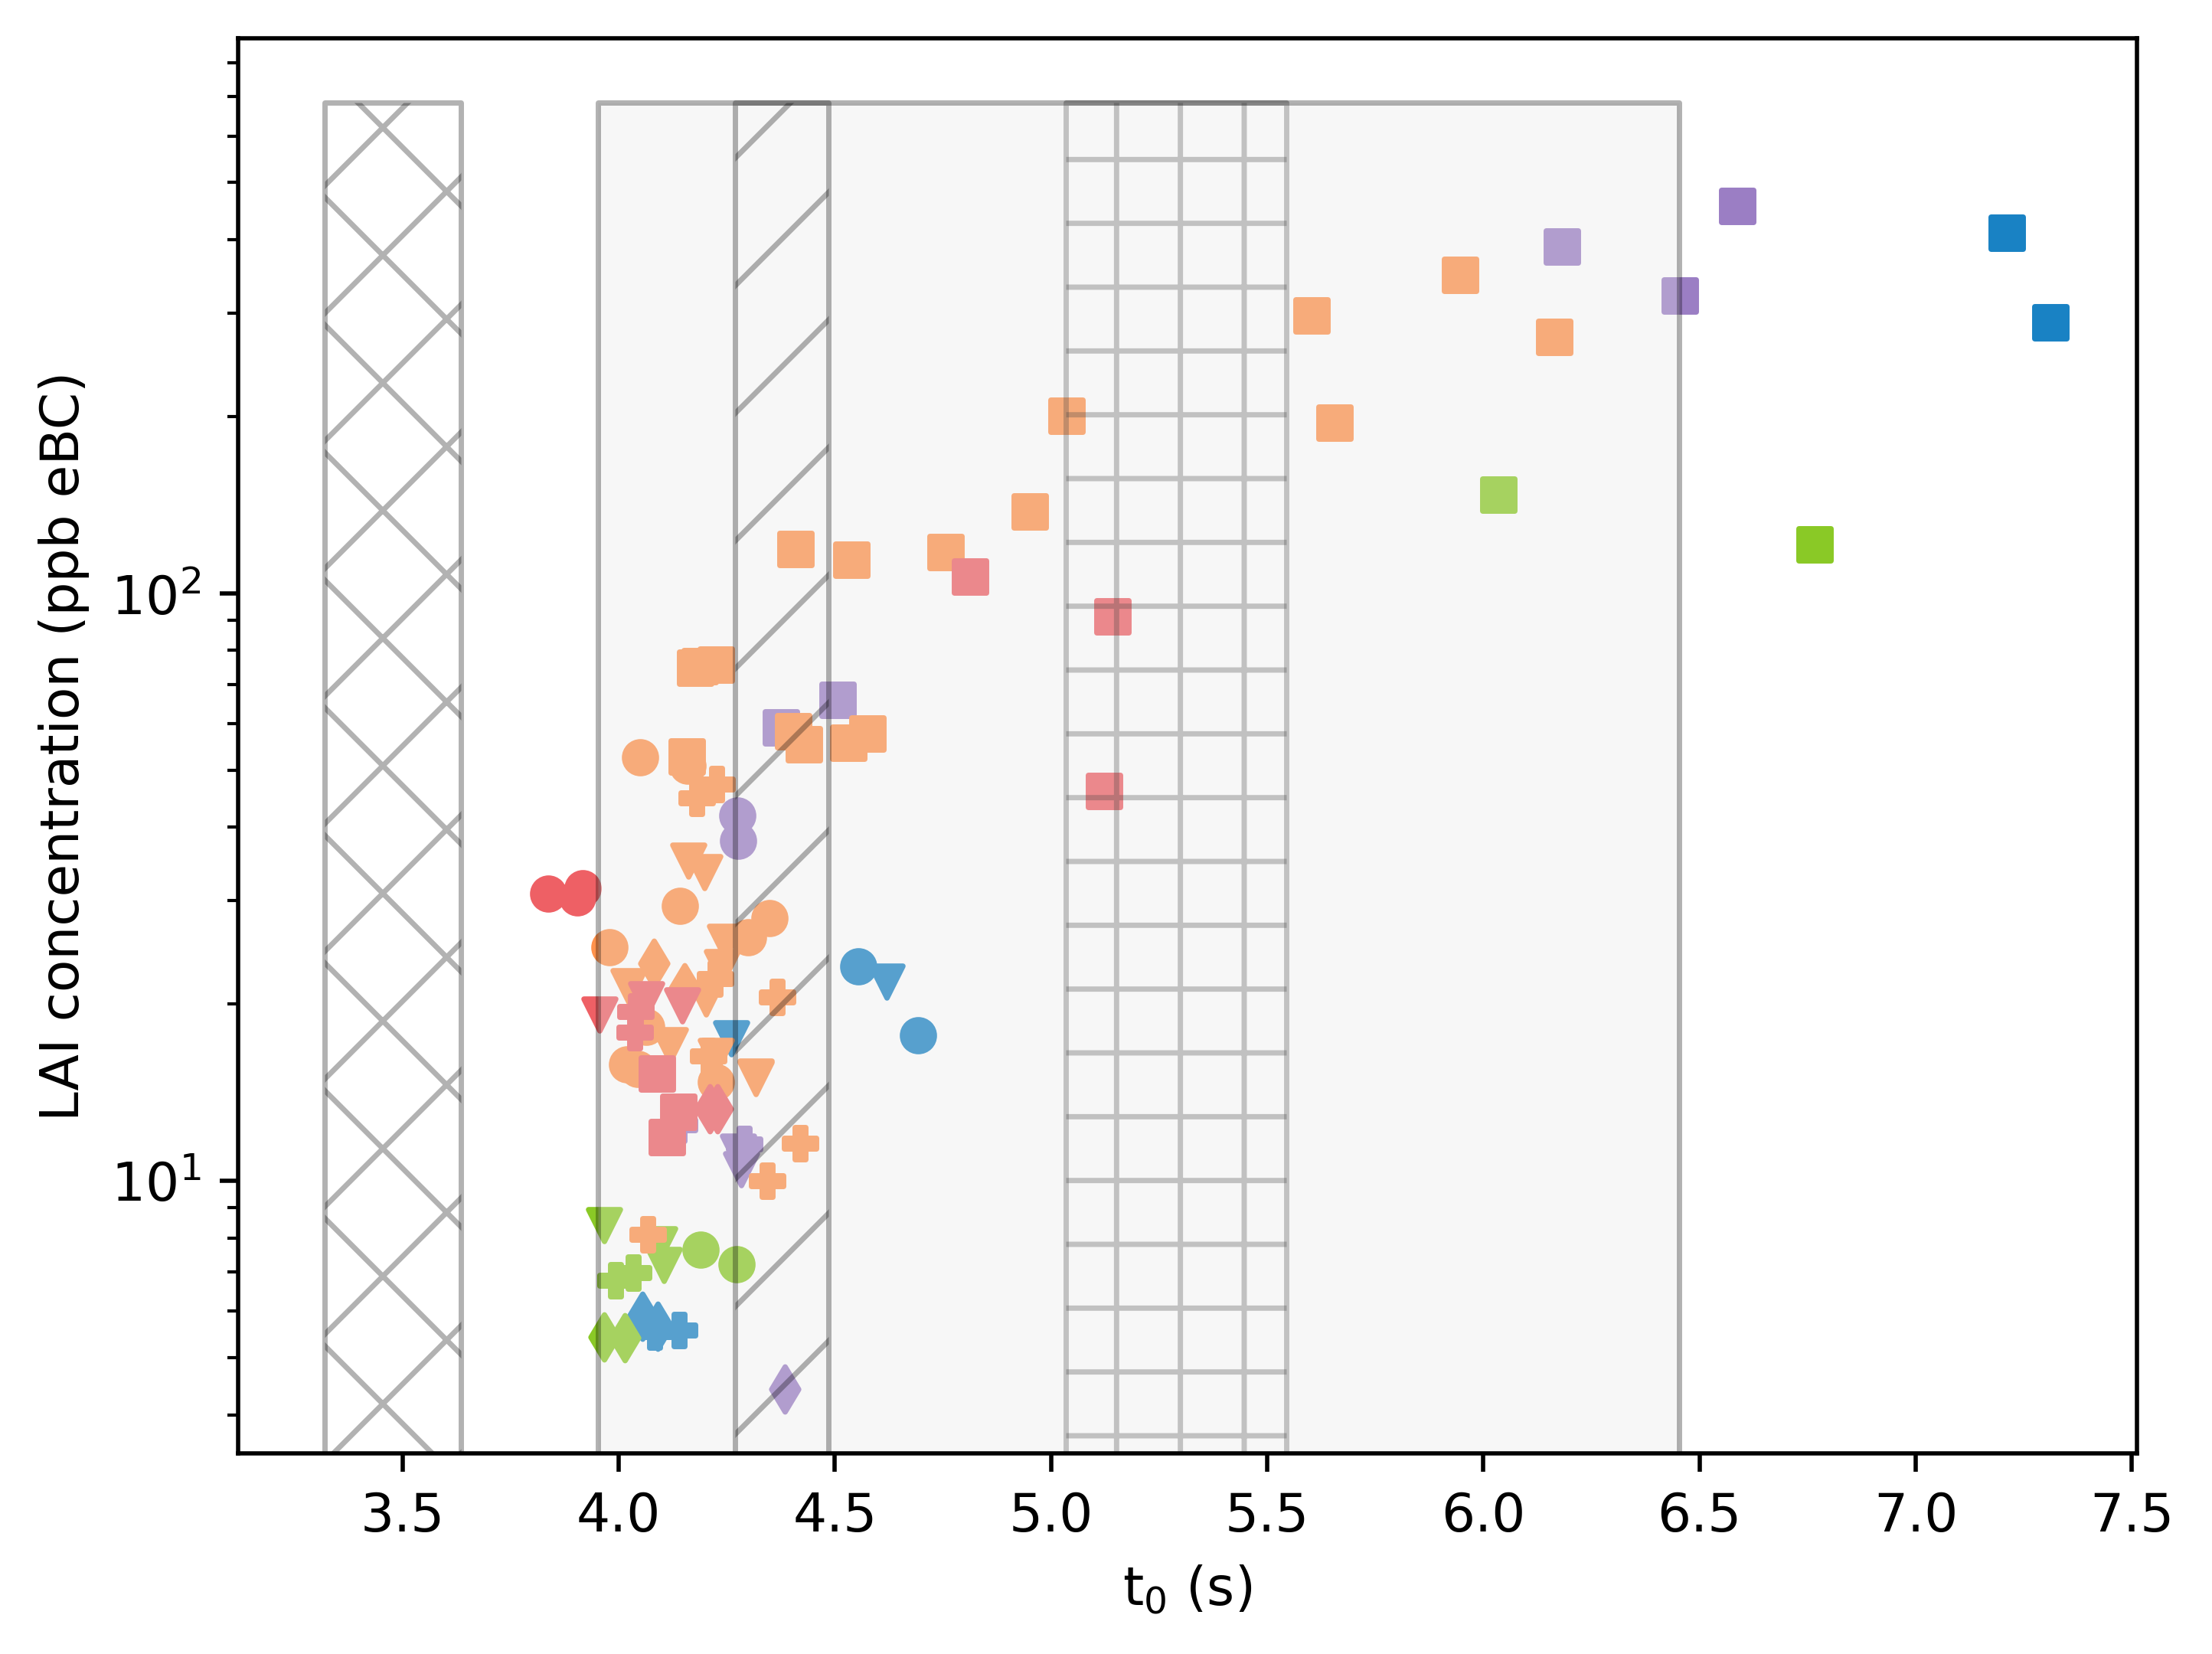

In [10]:
#shapes and colors
recty = [0,np.max(data['schmitt_ngperg'] * 1.5)]
plt.figure(dpi=500)
for isite in range(len(sitelist)):
    site = sitelist[isite]
    for idepth in range(len(depthlist)):
        depth = depthlist[idepth]   
        x = data['t0'][data['Site'] == site][data['Depth'] == depth]
        y = data['schmitt_ngperg'][data['Site'] == site][data['Depth'] == depth]
        plt.scatter(x,y, color = sitecolors[isite],label = 'site ' + str(site), marker = depthshapes[idepth])
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
# plt.grid(True)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
# plt.legend(loc = 'lower right')
plt.show()

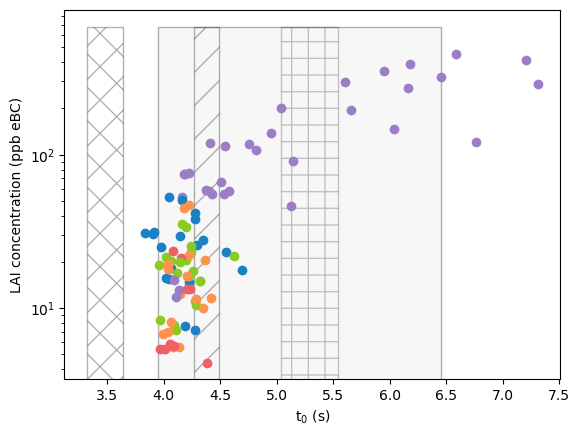

In [11]:
#colors as depths
siteshapes = ['s', 'o', 'v', 'P', 'd']
depthcolors = ['#9B7EC4', '#1982C4','#8AC926', '#FF924C', '#EE6065']
recty = [0,np.max(data['schmitt_ngperg'] * 1.5)]
# plt.figure(dpi=500)
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
for isite in range(len(sitelist)):
    site = sitelist[isite]
    for idepth in range(len(depthlist)):
        depth = depthlist[idepth]   
        x = data['t0'][data['Site'] == site][data['Depth'] == depth]
        y = data['schmitt_ngperg'][data['Site'] == site][data['Depth'] == depth]
        plt.scatter(x,y, color = depthcolors[idepth],label = 'depth ' + str(depth))
# plt.grid(True)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
# plt.legend(loc = 'lower right')
plt.show()

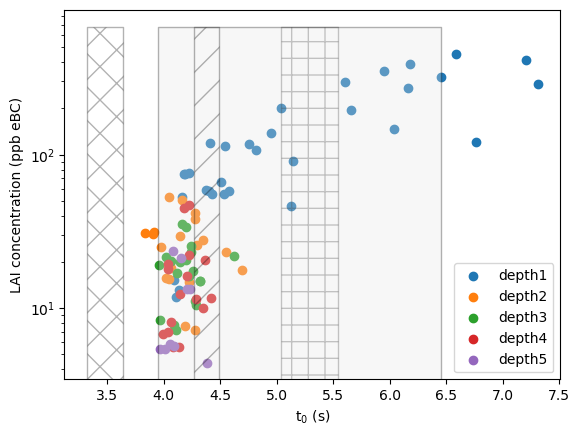

In [12]:
depthlist = [1,2,3,4,5]
# plt.figure(dpi=500)
for level in depthlist:
    x = data['t0'][data['Depth'] == level]
    y = data['schmitt_ngperg'][data['Depth'] == level]
    plt.scatter(x,y, label = 'depth' + str(level))
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
# plt.grid(True)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
plt.legend()
plt.show()

In [13]:
sitelist20 = [1,2,3,4]
sitelist21 = [7,8,9,10,11,13]
sitelist2021 = [1,2,3,4,7,8,9,10,11,13]

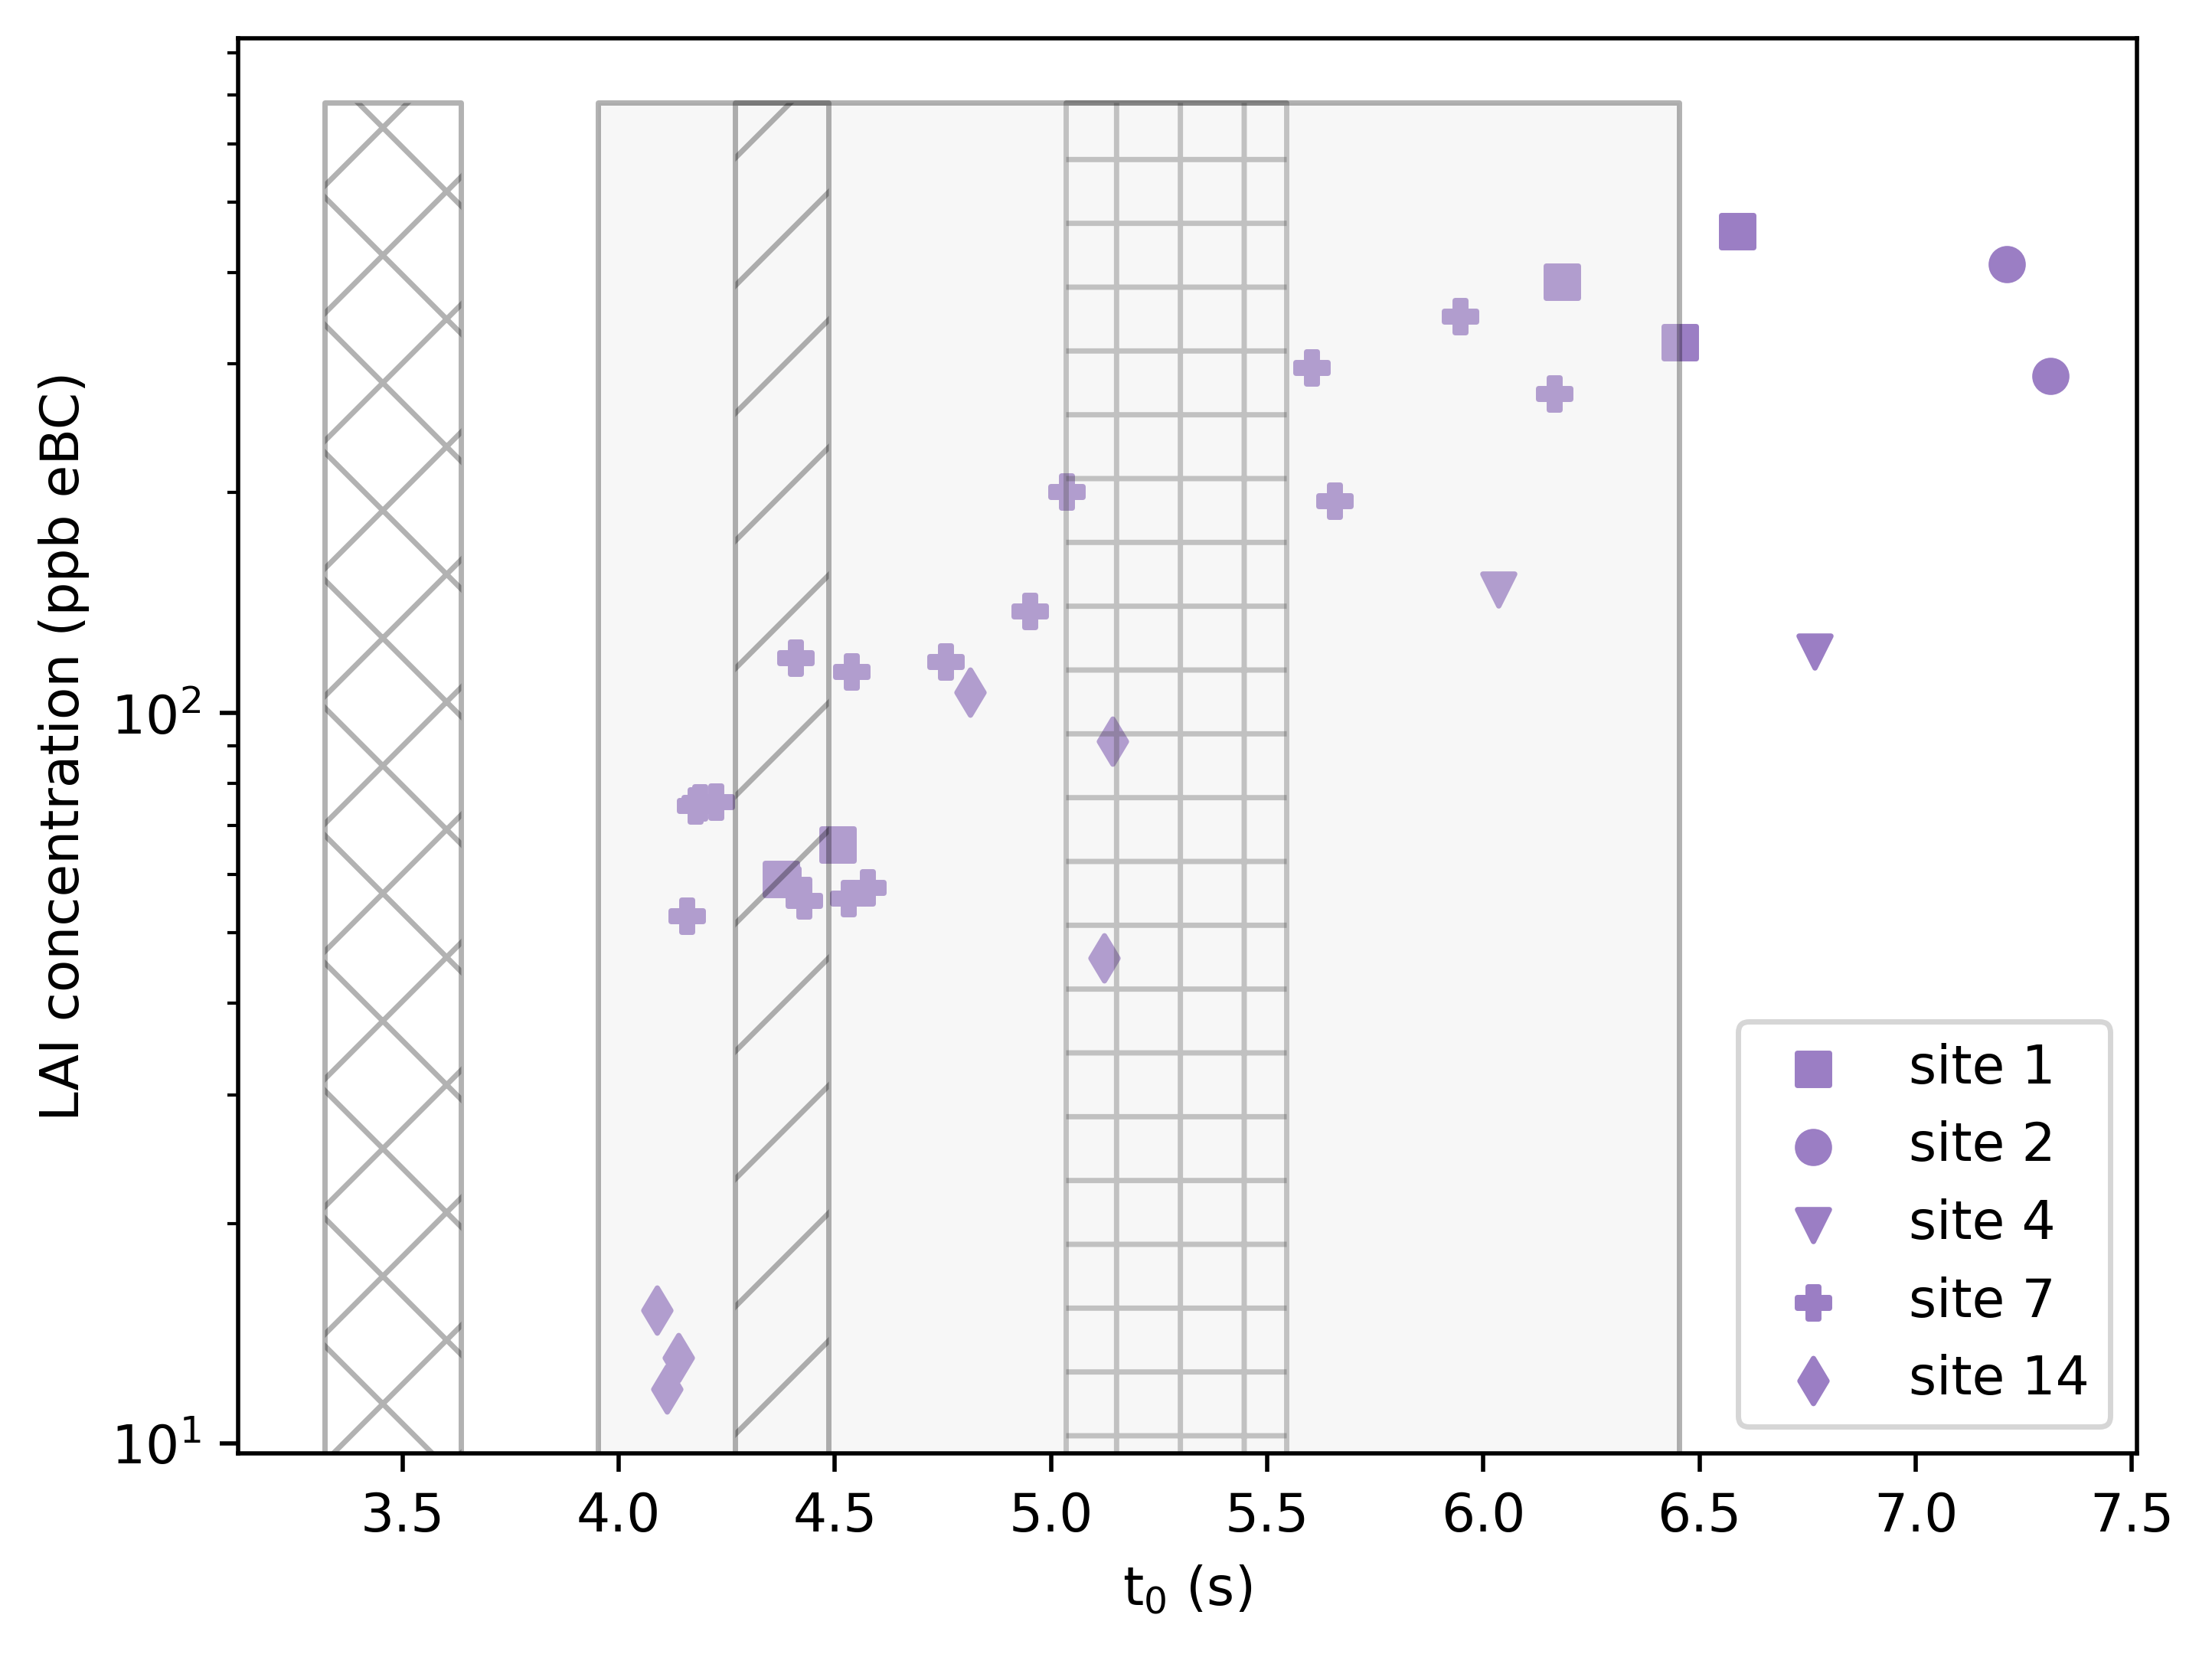

In [14]:
plt.figure(dpi=500)
index = 0
for site in sitelist:
    x = data['t0'][data['Site'] == site ][data['Depth'] == 1]
    y = data['schmitt_ngperg'][data['Site'] == site ][data['Depth'] == 1]
    plt.scatter(x,y, marker = siteshapes[index], label = 'site ' + str(site), color = '#9B7EC4')
    index += 1
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
plt.legend(loc = 'lower right')
plt.show()

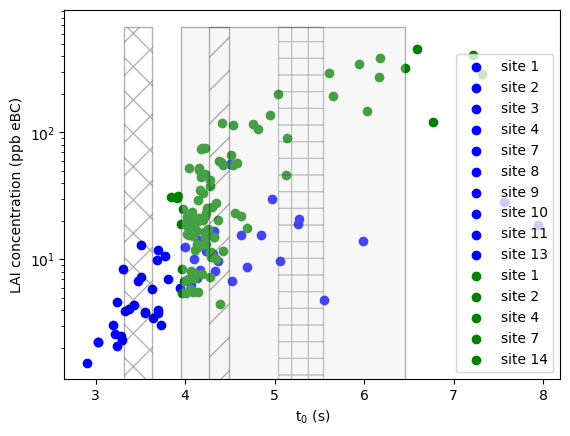

In [15]:
# plt.figure(dpi=500)
for site in sitelist2021:
    x = data21['t0'][data21['Site'] == site ]
    y = data21['schmitt_ngperg'][data21['Site'] == site ]
    plt.scatter(x,y, label = 'site ' + str(site), color = 'blue')
for site in sitelist:
    x = data['t0'][data['Site'] == site ]
    y = data['schmitt_ngperg'][data['Site'] == site ]
    plt.scatter(x,y, label = 'site ' + str(site), color = 'green')
plt.fill_betweenx(recty, pmean - pstd , pmean + pstd , facecolor = 'none', ec = 'black', hatch = '+', alpha =0.3)
plt.fill_betweenx(recty, dmean - dstd , dmean + dstd , facecolor = '#e7e7e7', ec = 'black', alpha =0.3)
plt.fill_betweenx(recty, emean - estd , emean + estd , facecolor = 'none', ec = 'black', hatch = 'x' , alpha =0.3)
plt.fill_betweenx(recty, fmean - fstd, fmean + fstd, facecolor = 'none', ec = 'black', hatch = '/', alpha =0.3)
plt.xlabel('t$_0$ (s)')
plt.ylabel('LAI concentration (ppb eBC)')
plt.yscale('log')
plt.legend(loc = 'lower right')
plt.show()

In [80]:
def yearavgs(depthlist, sitelist, dataxx):
    newdepthlist = []
    avgs = []
    sems = []
    for depth in depthlist:
        ngpergs = []
        
        for site in sitelist:
            x = dataxx['schmitt_ngperg'][dataxx['Site'] == site][dataxx['Depth'] == depth]
            for i in x.iloc:
                ngpergs.append(i)       
        if len(ngpergs) > 0:
            newdepthlist.append(depth)
            mean = np.mean(ngpergs)
            avgs.append(mean)
            sem = np.std(ngpergs, ddof=0) / np.sqrt(len(ngpergs))
            sems.append(sem)

            adjsppb = []
            for i in ngpergs:
                adj = i/3
                adjsppb.append(adj)
            
            adjsem = np.std(adjsppb, ddof=0) / np.sqrt(len(adjsppb))
            
  
    return avgs, sems, newdepthlist, adjsem

In [82]:
yearavgs_20 = yearavgs(depthlist, sitelist20, data21)
# print(yearavgs_20[0], yearavgs_20[1])
# print(yearavgs_20[0][0])

yearavgs_21 = yearavgs(depthlist, sitelist21, data21)

yearavgs_25 = yearavgs(depthlist, sitelist, data)
print(yearavgs_25[3])

[1.0166666666666666, 1.9533333333333334, 5.579999999999999, 2.4133333333333336, 3.3066666666666666]
[0.8333333333333334, 0.8666666666666667, 0.6866666666666666, 0.75, 1.47, 1.3066666666666666, 1.3499999999999999, 1.0166666666666666, 3.9333333333333336, 4.366666666666666]
[0.5133333333333333, 0.75, 0.7666666666666666, 2.7866666666666666]
[3.5766666666666667, 2.2600000000000002, 1.5466666666666666, 6.966666666666666, 5.2, 6.206666666666667, 4.693333333333333, 18.89, 9.423333333333334, 10.036666666666667, 6.359999999999999, 5.573333333333333, 3.6733333333333333, 3.2100000000000004]
[1.25, 1.2733333333333332, 1.3333333333333333, 3.3333333333333335, 1.9966666666666668, 3.236666666666667, 2.9, 4.713333333333334, 2.35, 5.156666666666667, 5.16, 2.7533333333333334, 2.393333333333333]
[1.1433333333333333, 1.27, 1.61, 2.263333333333333, 4.2, 3.8666666666666667, 2.7066666666666666, 2.4036666666666666, 2.11]
[151.9877788, 129.7225856, 107.11883016666667, 19.705103113333333, 21.976430476666668, 96.2

In [84]:
yearavgs_25[0][0] /= 3
yearavgs_25[1][0] /= 3
print(yearavgs_25[1][0])

7.373710942158961


In [86]:
width = 0.3
depth20 = [1-width, 2-width, 3-width]
depth25 = [1+width, 2+ width, 3+ width, 4, 5]

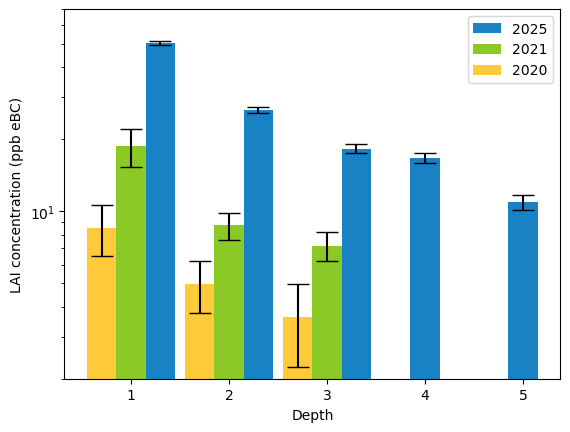

In [88]:
logflag = True
plt.bar(depth25, yearavgs_25[0], yerr = yearavgs_25[3], color = '#1982c4', width = width, log = logflag, capsize = 8, label = '2025')
plt.bar(yearavgs_21[2], yearavgs_21[0], yerr = yearavgs_21[1], color = '#8ac926', width = width, log = logflag, capsize = 8, label = '2021')
plt.bar(depth20, yearavgs_20[0], yerr = yearavgs_20[1], width = width, color = '#FFCA3A', log = logflag, capsize = 8, label = '2020')
# plt.errorbar(depthlist, yearavgs_25[0], yerr = yearavgs_25[1])
plt.legend()
plt.ylim([2,70])
plt.xlabel('Depth')
plt.ylabel('LAI concentration (ppb eBC)')
plt.show
plt.savefig('yty.png', dpi = 500)


In [ ]:
#Site 7 data 
site7 = [7]
def avgs7(depthlist, sitelist, dataxx):
    newdepthlist = []
    avgs = []
    sems = []
    for depth in depthlist:
        ngpergs = []
        for site in sitelist:
            x = dataxx['schmitt_ngperg'][dataxx['Site'] == site][dataxx['Depth'] == depth]
            for i in x.iloc:
                ngpergs.append(i)

            mean = np.mean(ngpergs)
            avgs.append(mean)
            sem = np.std(ngpergs, ddof=0) / np.sqrt(len(ngpergs))
            sems.append(sem)
  
    return avgs, sems

In [ ]:
data7 = avgs7(depthlist, site7, data)

In [ ]:
fig, ax = plt.subplots(dpi = 500)
index = 0
for depth in depthlist:
    x = data7[0][depth-1]
    ax.barh(depth, x, color = depthcolors[index], xerr = data7[1][depth-1], capsize = 8)
    index += 1
ax.invert_yaxis()
plt.xscale('log')
plt.xlabel('LAI concentration (ppb eBC)')
plt.figure(dpi = 200)
plt.show()

In [ ]:
date1 = '-06-06'
date2 = '-06-24'
date3 = '-03'
def seveninfo(depthlist, sitelist, dataxx, date):
    newdepthlist = []
    avgs = []
    sems = []
    for depth in depthlist:
        ngpergs = []   
        print('looking for match between', date, '&', str(dataxx['Sample']))
        
        if date in str(dataxx['Sample']):
            print('got a match')
            x = dataxx['schmitt_ngperg'][dataxx['Site'] == 7][dataxx['Depth'] == depth]
            for i in x.iloc:
                ngpergs.append(i)
                
        if len(ngpergs) > 0:
            newdepthlist.append(depth)
            mean = np.mean(ngpergs)
            avgs.append(mean)
            sem = np.std(ngpergs, ddof=1) / np.sqrt(len(ngpergs))
            sems.append(sem)
  
    return avgs, sems, newdepthlist

In [ ]:
#using a modified spreadsheet 
date1 = '06-06'
date2 = '06-24'
date3 = '07-03'
def seveninfo(depthlist, sitelist, dataxx, date):
    newdepthlist = []
    avgs = []
    sems = []
    for depth in depthlist:
        ngpergs = []
        x = dataxx['schmitt_ngperg'][dataxx['Site'] == 7][dataxx['Depth'] == depth][dataxx['Date'] == date]
        for i in x.iloc:
            ngpergs.append(i)
                
        if len(ngpergs) > 0:
            newdepthlist.append(depth)
            mean = np.mean(ngpergs)
            avgs.append(mean)
            sem = np.std(ngpergs, ddof=1) / np.sqrt(len(ngpergs))
            sems.append(sem)
  
    return avgs, sems, newdepthlist

In [ ]:
#trying to fix it 
# date1 = '-06-06'
# date2 = '-06-24'
# date3 = '-03'
# def seveninfo(depthlist, sitelist, dataxx, date):
#     newdepthlist = []
#     avgs = []
#     sems = []
    
#     # print('this is the full file ', dataxx)
#     # print('looking for match between', date, '&', str(dataxx['Sample']))    
    
#     for index in dataxx: 
#         print('row', row)
#         print('date', date)
#         if date in str(row):
#             print('got a match')
#             for depth in depthlist:
#                 ngpergs = [] 
#                 x = dataxx['schmitt_ngperg'][dataxx['Site'] == 7][dataxx['Depth'] == depth]
#                 for i in x.iloc:
#                     ngpergs.append(i)
                    
#             if len(ngpergs) > 0:
#                 newdepthlist.append(depth)
#                 mean = np.mean(ngpergs)
#                 avgs.append(mean)
#                 sem = np.std(ngpergs, ddof=1) / np.sqrt(len(ngpergs))
#                 sems.append(sem)
  
#     return avgs, sems, newdepthlist

In [ ]:
sixsix = seveninfo(depthlist, site7, datadates, date1)
sixtwofour = seveninfo(depthlist, site7, datadates, date2)
# print(sixtwofour)
seventhree = seveninfo(depthlist, site7, datadates, date3)
# print(seventhree)

sixsixloc = [i - width for i in sixsix[2]]
seventhreeloc = [i + width for i in seventhree[2]]

In [ ]:
logflag = True
plt.bar(sixsixloc, sixsix[0], yerr = sixsix[1], color = '#EE6065', width = width, log = logflag, capsize = 8, label = '6/6')
plt.bar(sixtwofour[2], sixtwofour[0], yerr = sixtwofour[1], color = '#8ac926', width = width, log = logflag, capsize = 8, label = '6/24')
plt.bar(seventhreeloc, seventhree[0], yerr = seventhree[1], width = width, color = '#FFCA3A', log = logflag, capsize = 8, label = '7/3')
# plt.errorbar(depthlist, yearavgs_25[0], yerr = yearavgs_25[1])
plt.legend()
plt.xlabel('Depth')
plt.ylabel('LAI concentration (ppb eBC)')
plt.show